In [32]:
import glob
import os

#get labeled data
labeled_csv_files = glob.glob(os.path.join('/Users/juliasantaniello/Desktop/NeuroLoop-Classification', '*LabeledData.csv'))

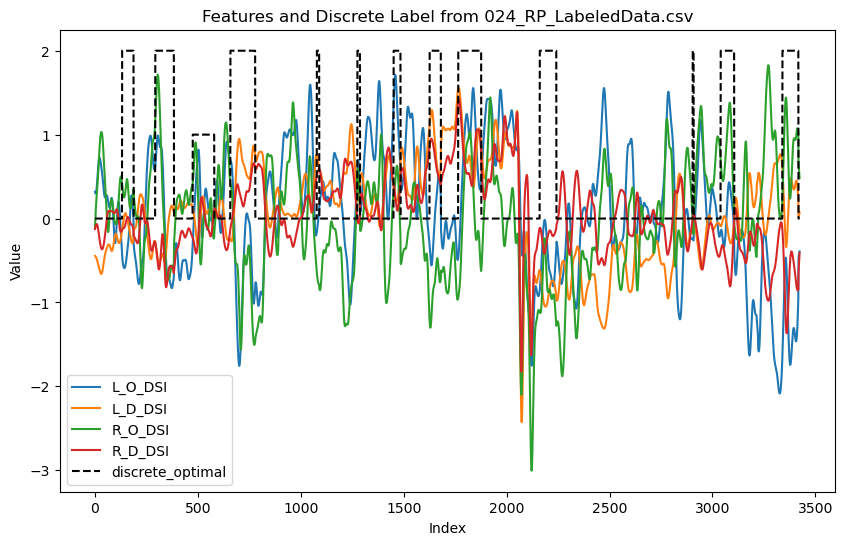

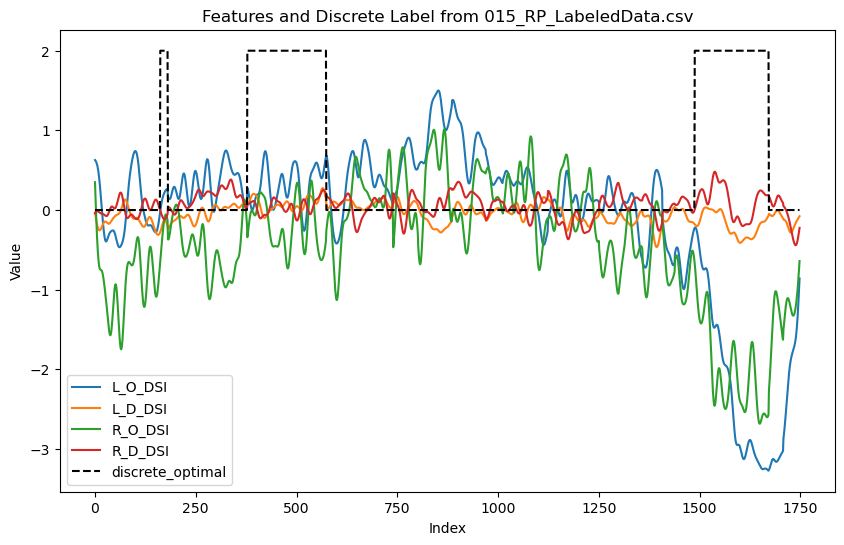

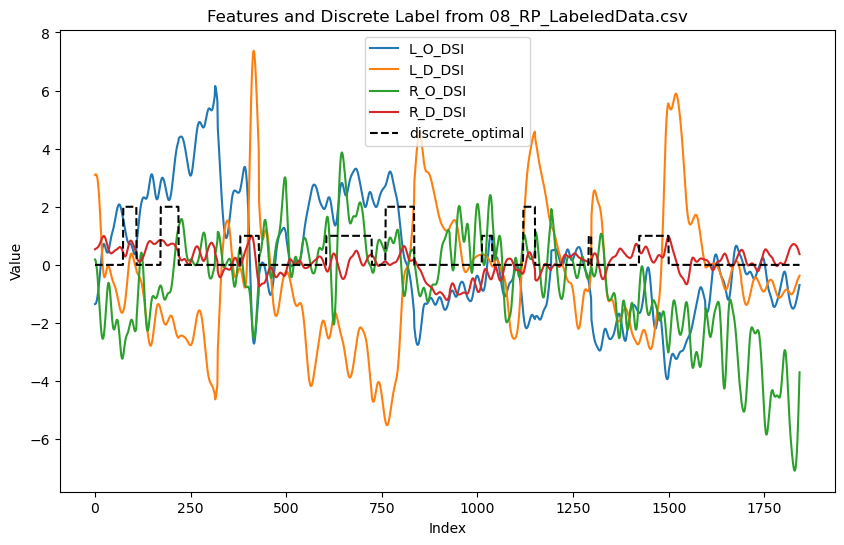

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

features = [
    'L_O_DSI', 'L_D_DSI', 'L_O_DSphi', 'L_D_DSphi',
    'R_O_DSI', 'R_D_DSI', 'R_O_DSphi', 'R_D_DSphi'
]
features = [
    'L_O_DSI', 'L_D_DSI', 
    'R_O_DSI', 'R_D_DSI'
]

for file in labeled_csv_files:
    df = pd.read_csv(file)
    plt.figure(figsize=(10, 6))
    for col in features:
        plt.plot(df[col], label=col)
    plt.plot(df['discrete_optimal'], label='discrete_optimal', linestyle='--', color='black')
    plt.title(f'Features and Discrete Label from {os.path.basename(file)}')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

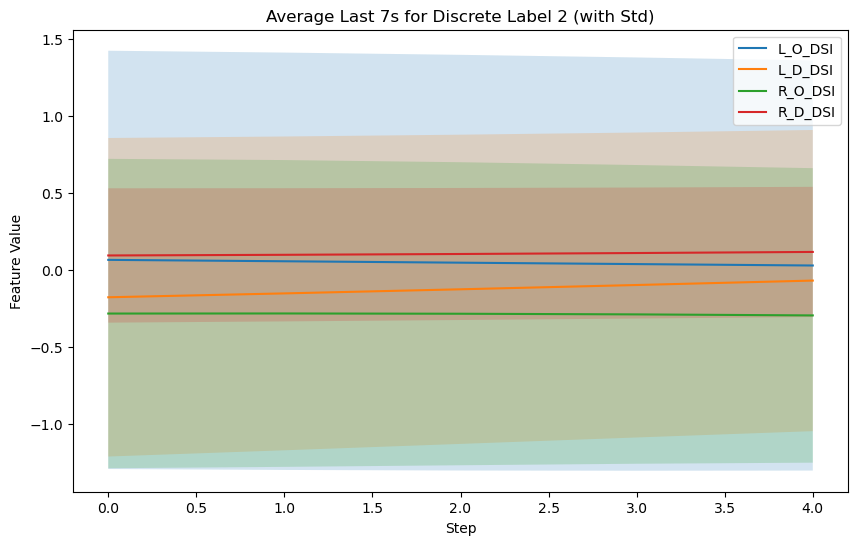

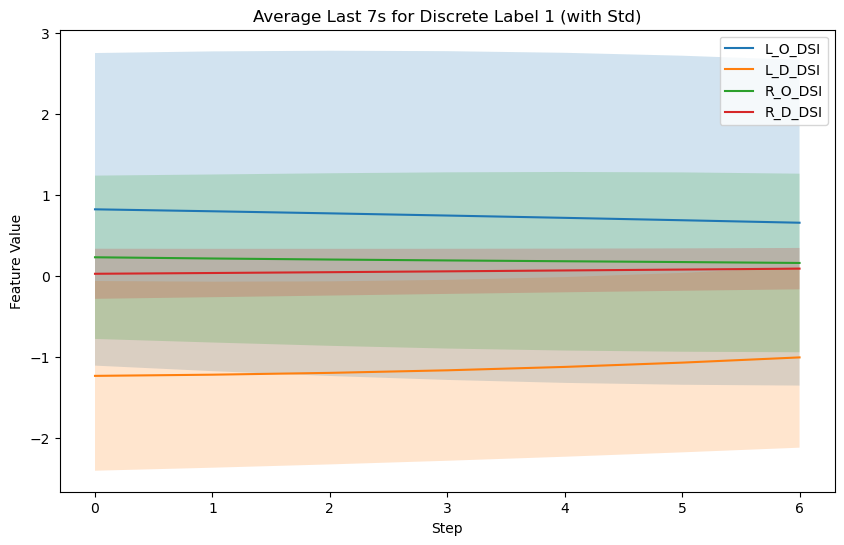

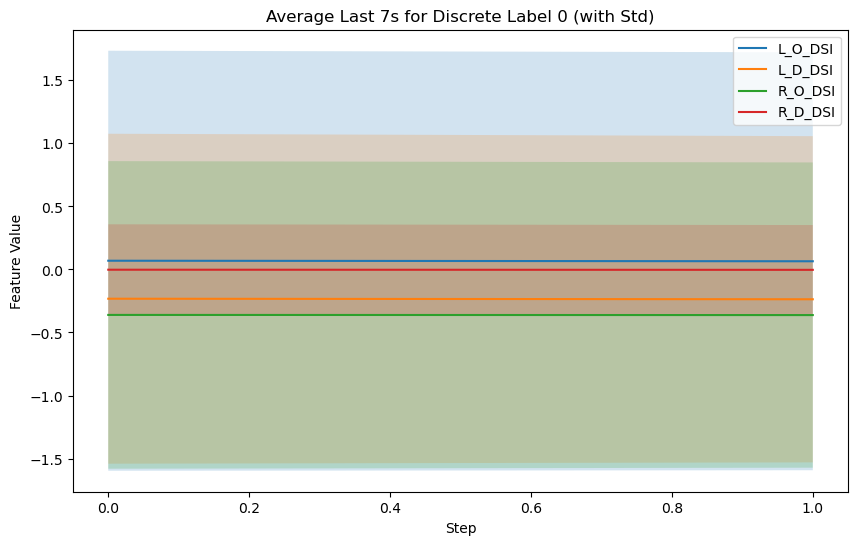

In [34]:
import numpy as np

# Store last 7 seconds by discrete label
last7s_by_label = {}

for file in labeled_csv_files:
    df = pd.read_csv(file)
    for ep, ep_df in df.groupby('episode'):
        # Convert time to pandas datetime
        ep_df = ep_df.copy()
        ep_df['time'] = pd.to_datetime(ep_df['time'])
        # Get last timestamp in episode
        t_end = ep_df['time'].iloc[-1]
        # Select last 7 seconds
        last7s = ep_df[ep_df['time'] >= t_end - pd.Timedelta(seconds=7)]
        # For each discrete_optimal value in this window, store features
        for label, group in last7s.groupby('discrete_optimal'):
            feats = group[features]
            if not feats.empty:
                last7s_by_label.setdefault(label, []).append(feats)

# Find min length for each label to align for averaging
min_lengths = {label: min(len(ep) for ep in eps) for label, eps in last7s_by_label.items()}

# Compute average and std for each label
avg_last7s = {}
std_last7s = {}
for label, eps in last7s_by_label.items():
    aligned = [ep.iloc[:min_lengths[label]] for ep in eps]
    stacked = np.stack([ep.values for ep in aligned])
    avg_last7s[label] = stacked.mean(axis=0)
    std_last7s[label] = stacked.std(axis=0)

# Plot
for label, avg_ep in avg_last7s.items():
    std_ep = std_last7s[label]
    plt.figure(figsize=(10, 6))
    for i, feat in enumerate(features):
        plt.plot(avg_ep[:, i], label=feat)
        plt.fill_between(
            range(avg_ep.shape[0]),
            avg_ep[:, i] - std_ep[:, i],
            avg_ep[:, i] + std_ep[:, i],
            alpha=0.2
        )
    plt.title(f'Average Last 7s for Discrete Label {label} (with Std)')
    plt.xlabel('Step')
    plt.ylabel('Feature Value')
    plt.legend()
    plt.show()


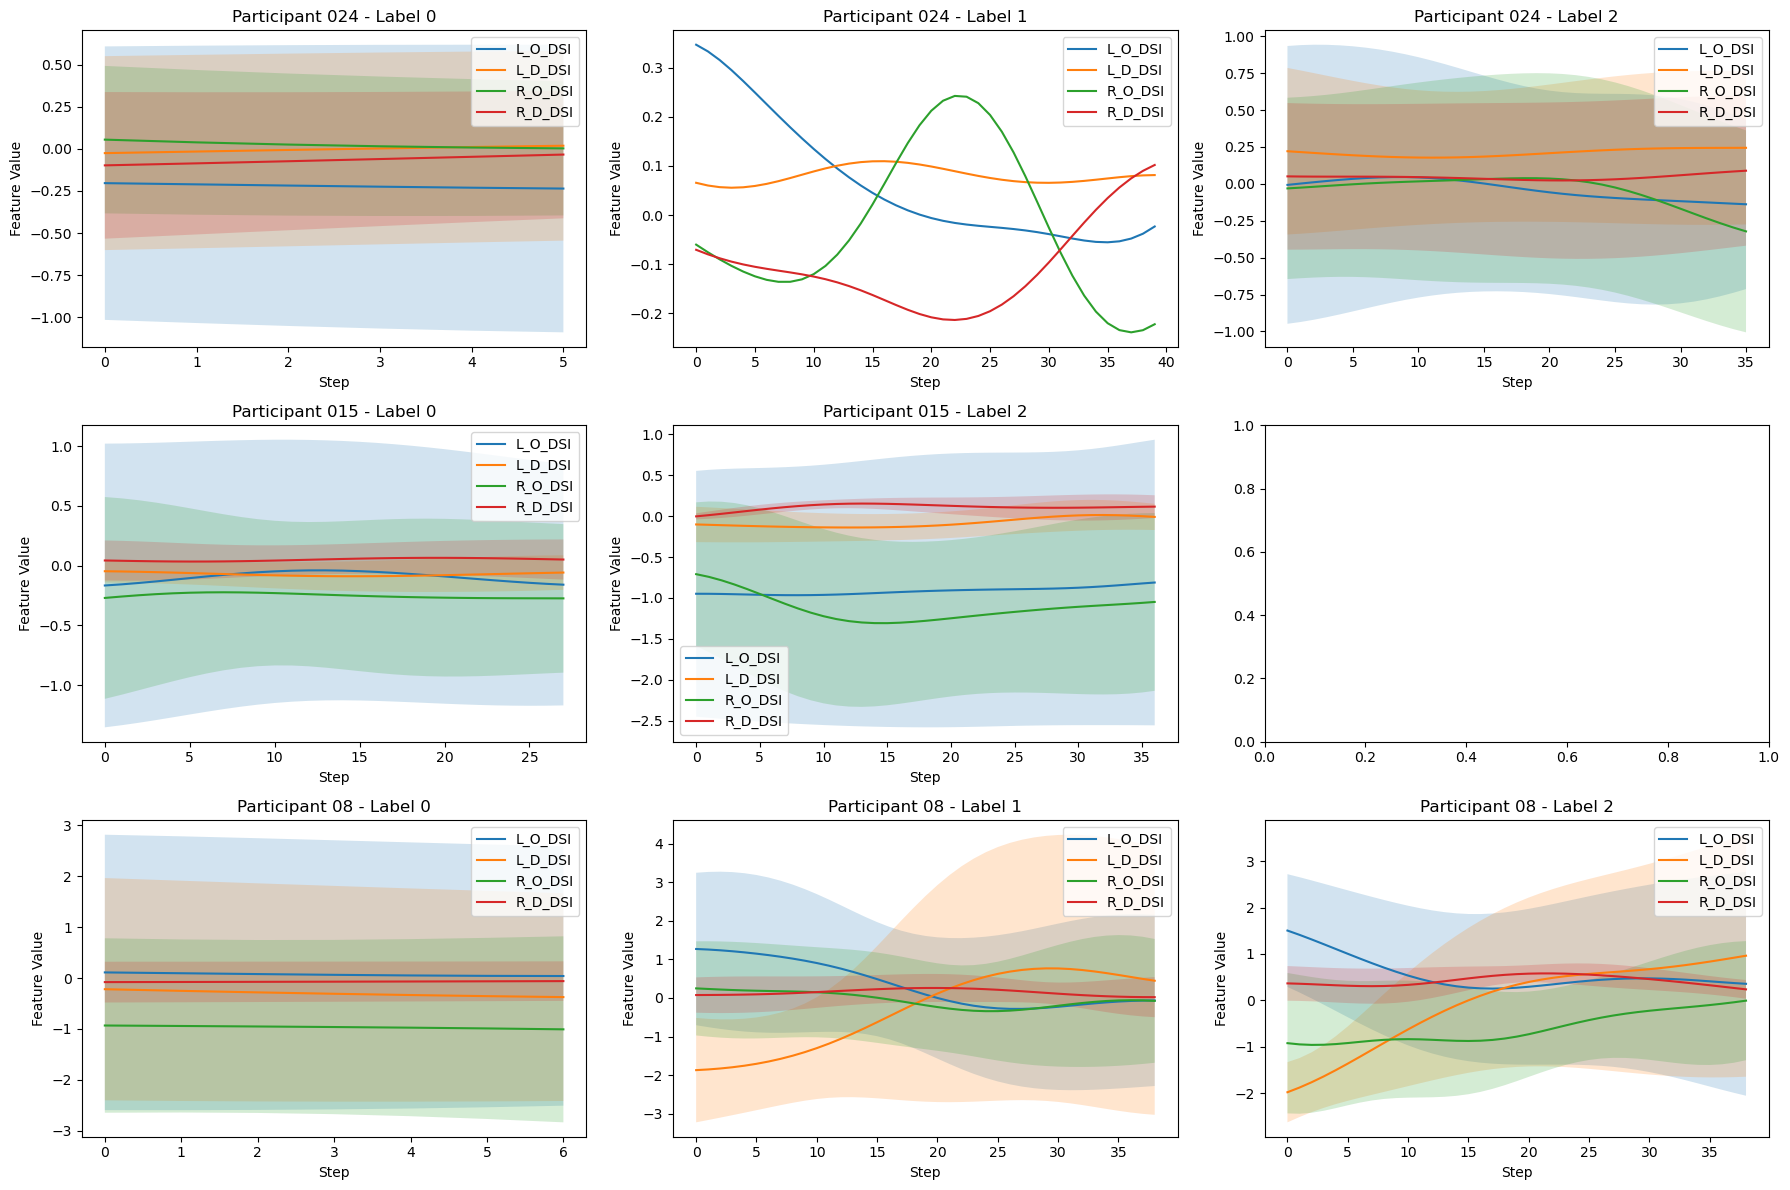

In [35]:
participant_files = {}
for file in labeled_csv_files:
    # Extract participant ID from filename (e.g., '009' from '009_RP_LabeledData.csv')
    participant_id = os.path.basename(file).split('_')[0]
    participant_files.setdefault(participant_id, []).append(file)

n_participants = len(participant_files)
n_labels = len(set(min_lengths.keys()))

fig, axes = plt.subplots(n_participants, n_labels, figsize=(6 * n_labels, 4 * n_participants), squeeze=False)

for row, (participant_id, files) in enumerate(participant_files.items()):
    # Collect last 7s by label for this participant
    last7s_by_label_participant = {}
    for file in files:
        df = pd.read_csv(file)
        for ep, ep_df in df.groupby('episode'):
            ep_df = ep_df.copy()
            ep_df['time'] = pd.to_datetime(ep_df['time'])
            t_end = ep_df['time'].iloc[-1]
            last7s = ep_df[ep_df['time'] >= t_end - pd.Timedelta(seconds=7)]
            label = last7s['discrete_optimal'].iloc[-1]
            feats = last7s[features].reset_index(drop=True)
            if not feats.empty:
                last7s_by_label_participant.setdefault(label, []).append(feats)
    # Find min length for each label
    min_lengths = {label: min(len(ep) for ep in eps) for label, eps in last7s_by_label_participant.items()}
    # Compute avg and std
    avg_episodes = {}
    std_episodes = {}
    for label, eps in last7s_by_label_participant.items():
        aligned = [ep.iloc[:min_lengths[label]] for ep in eps]
        stacked = np.stack([ep.values for ep in aligned])
        avg_episodes[label] = stacked.mean(axis=0)
        std_episodes[label] = stacked.std(axis=0)
    # Plot
    for col, label in enumerate(sorted(avg_episodes.keys())):
        avg_ep = avg_episodes[label]
        std_ep = std_episodes[label]
        ax = axes[row, col]
        for i, feat in enumerate(features):
            ax.plot(avg_ep[:, i], label=feat)
            ax.fill_between(
                range(avg_ep.shape[0]),
                avg_ep[:, i] - std_ep[:, i],
                avg_ep[:, i] + std_ep[:, i],
                alpha=0.2
            )
        ax.set_title(f'Participant {participant_id} - Label {label}')
        ax.set_xlabel('Step')
        ax.set_ylabel('Feature Value')
        ax.legend()
plt.tight_layout()
plt.show()